In [ ]:
from sallypy.repos import TimeSeriesRepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ts_repo = TimeSeriesRepo()


returns = ts_repo.get_monthly_returns(["BMK0017", "BMK0188"])

returns.columns = ["Bonds", "Stocks"]

In [2]:

def simulate_returns(n, s, cov, exp_ret):
    """

    Parameters
    ----------
    n : int
        Number of simulations.
    s : int
        Length of the simulation.
    cov : pandas.DataFrame
        Covariance matrix.
    exp_ret : pandas.Series
        Expected returns.

    Returns
    -------
    np.array
        Simulated returns.

    """
    L = np.linalg.cholesky(cov)
    num_assets = len(exp_ret)
    simulated_returns = np.zeros((n, num_assets, s))
    for i in range(n):
        z = np.random.normal(size=(num_assets, s))
        simulated_returns[i] = exp_ret.values[:, None] + L @ z
    return simulated_returns
cov = returns.cov()
exp_ret = returns.mean()

n = 40000
T = 12*30
simulated_returns = simulate_returns(n, T, cov, exp_ret)



w_bonds = 0
w_stocks = 1 - w_bonds

weights = np.zeros((T, 2))
weights[:, 0] = w_bonds

weights[:, 1] = w_stocks
wealth = np.zeros((n, T+1))
initial_wealth = 1e6
wealth[:, 0] = initial_wealth

withdrawal = 0.04 * initial_wealth / 12

inflation = 0.03 #annual inflation
monthly_inflation = (1 + inflation)**(1/12) - 1

inflation_adjustment = 1

for i in range(T):
    wealth[:, i+1] = wealth[:, i] * (1 + weights[i, 0] * simulated_returns[:, 0, i] + weights[i, 1] * simulated_returns[:, 1, i]) - withdrawal * inflation_adjustment
    wealth[wealth[:, i+1] < 0, i+1] = 0
    inflation_adjustment *= (1 + monthly_inflation)


In [3]:
def destitution_risk(wealth, threshold):
    """
    Parameters
    ----------
    wealth : np.array
        Wealth paths.
    threshold : float
        Threshold.

    Returns
    -------
    np.array
        Destitution risk.

    """
    return np.sum(wealth[:,-1] <= threshold) / len(wealth)

def median_wealth(wealth):
    """
    Parameters
    ----------
    wealth : np.array
        Wealth paths.

    Returns
    -------
    np.array
        Median wealth.

    """
    return np.median(wealth, axis=0)


In [4]:
wealth[:,-1].shape

(40000,)

In [5]:
destitution_risk(wealth, 0)

np.float64(0.09975)

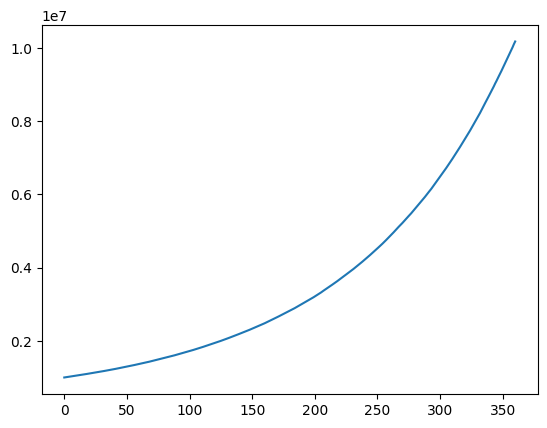

In [6]:
plt.plot(wealth.mean(axis=0))

In [7]:
import torch

torch.autograd.set_detect_anomaly(True)

annual_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
annual_returns = annual_returns.dropna()

annual_exp_ret = annual_returns.mean()
# annual_exp_ret = pd.Series([0.0424, 0.07874999999999999])
annual_cov = annual_returns.cov()


n = 100000
T = 30


t_returns = torch.tensor(simulate_returns(n, T, annual_cov, annual_exp_ret))
val_returns = torch.tensor(simulate_returns(n, T, annual_cov, annual_exp_ret))




weights = torch.full((T, 1), 0.1, requires_grad=True)

# random initial weights
# weights = torch.rand((T, 1), requires_grad=True)

# Clamp the weights to be between 0 and 1
weights.data.clamp_(0.0, 1.0)

optimizer = torch.optim.Adam([weights], lr=0.01)

inflation = 0.03 #annual inflation
monthly_inflation = (1 + inflation)**(1/12) - 1
initial_wealth = 6e5
withdrawal = 0.04 * initial_wealth

def cost(wealth, weights):
    return -torch.mean(wealth)/initial_wealth + 0.5*torch.std(wealth/initial_wealth) + torch.sum((weights-torch.mean(weights))**2)/10 


def semi_variance(wealth, threshold):
    return torch.mean((wealth - threshold).clamp(0)**2)


def cost(wealth, weights):
    cost_ =  -torch.sigmoid(wealth/initial_wealth).sum()/n
    for z in range(1, 5):
        cost_ += torch.sum((weights[z:] - weights[:-z])**2)/(z*50)
    return cost_


# def cost(wealth):
#     "Destitution risk"
#     return torch.sum(wealth < 0)

last_loss = 0


In [8]:

for z in range(1000):
    optimizer.zero_grad()
    simulated_returns = t_returns

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1
    wealth_over_time = np.zeros((T, n))
    for i in range(T):
        withdrawal = wealth.detach() * 0.05
    
        withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)

        wealth = wealth * (1 + weights[i, 0] * simulated_returns[:, 0, i] + (1-weights[i, 0]) * simulated_returns[:, 1, i]) - withdrawal 
        # replace negative wealth with 0
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        wealth_over_time[i] = wealth.detach().numpy().flatten()
        inflation_adjustment *= (1 + inflation)
        
    loss = cost(wealth, weights)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        weights.clamp_(0.0, 1.0)
    print(loss.item())
    print(weights.mean())
    print("destitution risk", torch.sum(wealth <= 0).item()/n)
    # validation

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1

    for i in range(T):
        withdrawal = wealth.detach() * 0.05
        withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)
        wealth = wealth * (1 + weights[i, 0] * val_returns[:, 0, i] + (1-weights[i, 0]) * val_returns[:, 1, i]) - withdrawal
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        inflation_adjustment *= (1 + inflation)
    print("validation destitution risk", torch.sum(wealth <= 0).item()/n)
    
    if z>10 and last_loss - loss.item() < 1e-8:
        break
    last_loss = loss.item()



-0.7258843408855511
tensor(0.1027, grad_fn=<MeanBackward0>)
destitution risk 0.44598
validation destitution risk 0.44642
-0.7261523667849761
tensor(0.1052, grad_fn=<MeanBackward0>)
destitution risk 0.44605
validation destitution risk 0.4464
-0.7264074589333045
tensor(0.1079, grad_fn=<MeanBackward0>)
destitution risk 0.44622
validation destitution risk 0.44637
-0.7266198628069603
tensor(0.1106, grad_fn=<MeanBackward0>)
destitution risk 0.44627
validation destitution risk 0.44675
-0.7268105272392545
tensor(0.1133, grad_fn=<MeanBackward0>)
destitution risk 0.44656
validation destitution risk 0.44686
-0.7269858377182083
tensor(0.1160, grad_fn=<MeanBackward0>)
destitution risk 0.44678
validation destitution risk 0.44708
-0.7271325812272607
tensor(0.1187, grad_fn=<MeanBackward0>)
destitution risk 0.44697
validation destitution risk 0.44718
-0.7272549499848587
tensor(0.1215, grad_fn=<MeanBackward0>)
destitution risk 0.44726
validation destitution risk 0.44758
-0.7273599994461694
tensor(0.1243

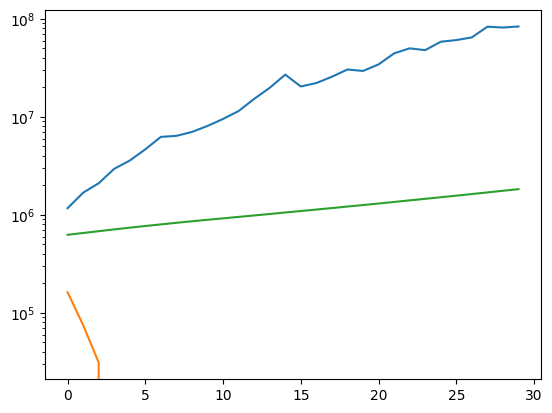

In [9]:
from matplotlib import pyplot as plt
plt.plot(np.max(wealth_over_time, axis=1))
plt.plot(np.min(wealth_over_time, axis=1))
plt.plot(np.mean(wealth_over_time, axis=1))
plt.yscale("log")

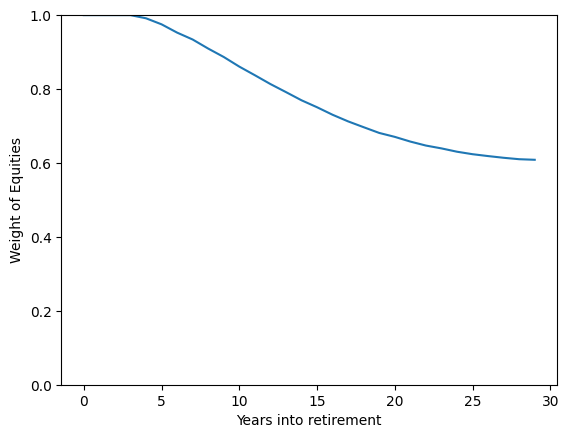

In [10]:
plt.plot(1-weights.detach().numpy())  
plt.xlabel("Years into retirement")
plt.ylabel("Weight of Equities")
plt.ylim(0, 1)
plt.show()

In [ ]:
returns = ts_repo.get_monthly_returns(["BMK0017", "BMK0188", "BFS_OCR.25"])
from IPython.display import clear_output

import torch

returns.columns = ["Bonds", "Stocks", "Cash"]

annual_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
annual_returns = annual_returns.dropna()

annual_exp_ret = annual_returns.mean()
annual_cov = annual_returns.cov()

n = 100000
T = 61
RETIRE_YEAR = 30

t_returns = torch.tensor(simulate_returns(n, T, annual_cov, annual_exp_ret))
val_returns = torch.tensor(simulate_returns(n, T, annual_cov, annual_exp_ret))

weights = torch.full((T, 2), 0.5, requires_grad=True)

# random initial weights
# weights = torch.rand((T, 2), requires_grad=True)

# Clamp the weights to be between 0 and 1
weights.data.clamp_(0.0, 1.0)

optimizer = torch.optim.Adam([weights], lr=0.01)

inflation = 0.03 #annual inflation
monthly_inflation = (1 + inflation)**(1/12) - 1
initial_wealth = 1e1
withdrawal = 0.04 * initial_wealth

def cost(wealth, weights, smoothing_weight=1/10, alpha=0.5, sharpness=1e-6):
    cost_ = -torch.sigmoid(wealth * sharpness).sum()/n
    s_m1 = weights[0, :]
    for z in range(1, weights.shape[0]):
        s_m1 = weights[z, :]
        x_z = weights[z-1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing_weight
        
    return cost_


def cost_2(w_t, weights, smoothing_weight=1/10, alpha=0.5):
    sharpness = 6
    norm_w_t = ((w_t.T / w_t.mean(axis=1))).T

    cost_ = -torch.sigmoid(w_t).sum()/n/T

    # Pre-retirement smoothing

    s_m1 = weights[0, :]
    for z in range(1, RETIRE_YEAR):
        s_m1 = weights[z, :]
        x_z = weights[z-1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing_weight

    # Post-retirement smoothing

    s_m1 = weights[RETIRE_YEAR, :]
    for z in range(1, T-RETIRE_YEAR):
        s_m1 = weights[RETIRE_YEAR+z, :]
        x_z = weights[RETIRE_YEAR+z-1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing_weight
        
    return cost_

# def cost(wealth, weights, smoothing_weight=1/10, alpha=0.5):
#     cost_ =  -torch.sigmoid(wealth/initial_wealth).sum()/n
#     for z in range(1, 5):
#         cost_ += torch.sum((weights[z:] - weights[:-z])**2)/(z*50)
#     return cost_


last_loss = 0
z = 0


smoothing_weight = 0
alpha = 0.8
base_iter_stop = 2000
iter_stop = base_iter_stop

withdrawal_base = [-10000] * RETIRE_YEAR + [40000] * (T-RETIRE_YEAR)

sharpness = 1e-6
while z < iter_stop:
    
    optimizer.zero_grad()
    simulated_returns = t_returns

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1
    wealth_over_time = np.zeros((T, n))
    w_t = torch.zeros((T, n))
    for i in range(T):
        # withdrawal = wealth.detach() * 0.05
    
        # withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)

        withdrawal = withdrawal_base[i] * inflation_adjustment
        withdrawal = torch.ones(n) * withdrawal

        cash_weight = 1 - weights[i, 0] 
        bond_weight = weights[i, 0] * weights[i, 1]
        stock_weight = weights[i, 0] * (1 - weights[i, 1])
        wealth = wealth * (1 + cash_weight * simulated_returns[:, 2, i] + bond_weight * simulated_returns[:, 0, i] + stock_weight * simulated_returns[:, 1, i]) - withdrawal
        # replace negative wealth with 0
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        w_t[i] = wealth
        wealth_over_time[i] = wealth.detach().numpy().flatten()
        inflation_adjustment *= (1 + inflation)
        
    loss = cost(wealth, weights, smoothing_weight, alpha)
    # loss = cost_2(w_t, weights, smoothing_weight, alpha)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        weights.clamp_(0.0, 1.0)
    print(loss.item())
    print(f"cash weight: {1-weights.mean(dim=0)[0].item()}")
    print(f"bond weight: {weights.mean(dim=0)[0].item() * weights.mean(dim=0)[1].item()}")
    
    print("destitution risk", torch.sum(wealth <= 0).item()/n)
    print("mean final wealth", torch.mean(wealth).item())
    # validation

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1

    for i in range(T):
        # withdrawal = wealth.detach() * 0.05
        # withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)
        withdrawal = withdrawal_base[i] * inflation_adjustment
        withdrawal = torch.ones(n) * withdrawal
        cash_weight = 1 - weights[i, 0] 
        bond_weight = weights[i, 0] * weights[i, 1]
        stock_weight = weights[i, 0] * (1 - weights[i, 1])
        wealth = wealth * (1 + cash_weight * val_returns[:, 2, i] + bond_weight * val_returns[:, 0, i] + stock_weight * val_returns[:, 1, i]) - withdrawal
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        inflation_adjustment *= (1 + inflation)
    print("validation destitution risk", torch.sum(wealth <= 0).item()/n)
    print("validation mean final wealth", torch.mean(wealth).item())
    print("iteration", z)
    print("smoothing weight", smoothing_weight)
    print("alpha", alpha)
    clear_output(wait=True)

    # if z>10 and last_loss - loss.item() < 1e-8 and base_iter_stop == iter_stop:
    if z == base_iter_stop - 1:
        iter_stop = z + 3000
        alpha = 0.85
        smoothing_weight = 1/100

    if z == 100:
        sharpness = 1e-5
    if z == 300:
        sharpness = 1e-4
    if z == 700:
        sharpness = 1e-3
    if z == 1100:
        sharpness = 1e-2
    if z == 1500:
        sharpness = 1e-1
    z += 1
    last_loss = loss.item()


KeyboardInterrupt: 

In [37]:

def simulate_returns(n, s, cov, exp_ret):
    """

    Parameters
    ----------
    n : int
        Number of simulations.
    s : int
        Length of the simulation.
    cov : pandas.DataFrame
        Covariance matrix.
    exp_ret : pandas.Series
        Expected returns.

    Returns
    -------
    np.array
        Simulated returns.

    """
    # for i in range(n):
    #     z = np.random.normal(size=(num_assets, s))
    #     simulated_returns[i] = exp_ret.values[:, None] + L @ z
    L = np.linalg.cholesky(cov)
    num_assets = len(exp_ret)
    simulated_returns = np.zeros((n, s, num_assets))
    z = np.random.normal(size=(n, s, num_assets))
    exp_ret = exp_ret.values
    exp_ret = np.tile(exp_ret, (n, s, 1))
    simulated_returns = exp_ret + z @ L.T
    return np.rot90(simulated_returns, k=1, axes=(1, 2))

In [38]:
returns = ts_repo.get_monthly_returns(tickers= ["CNZ_MPF_NONE_2080", "CNZ_MPF_NONE_3070", "CNZ_MPF_NONE_4060",]) #"CNZ_MPF_NONE_5050", "CNZ_MPF_NONE_6040", "CNZ_MPF_NONE_7030", "CNZ_MPF_NONE_8020", "CNZ_MPF_NONE_9010", "CNZ_MPF_NONE_9802",])
returns.columns = returns.columns.get_level_values(0)

# annual_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
annual_returns = returns.dropna()

annual_exp_ret = annual_returns.mean()
annual_cov = annual_returns.cov()


In [41]:

n = 10000
T = 60 * 24
import time

start = time.time()
simulated_returns = simulate_returns(n, T, annual_cov, annual_exp_ret)
print("Simulated returns", time.time() - start)

weights = np.full((T, len(annual_returns.columns)), 1/len(annual_returns.columns))

initial_wealth = 1e2

wealth = np.zeros((n, T+1))
wealth[:, 0] = initial_wealth

cashflows = np.ones(T) * 1e3 * 0
time_deltas = np.random.exponential(12, T)
time_steps = np.zeros(T+1)
time_steps[1:] = np.cumsum(time_deltas)

start = time.time()
for i in range(T):
    wealth[:, i+1] = wealth[:, i] * (weights[i]*(1+simulated_returns[:, :, i])**time_deltas[i]).sum(axis=1) + cashflows[i] 
    wealth[wealth[:, i+1] < 0, i+1] = 0

print("Wealth simulation", time.time() - start)

Simulated returns 0.830711841583252
Wealth simulation 1.001941442489624


In [31]:
wealth.shape

(10000, 61)

In [25]:
(weights[i]*(1+simulated_returns[:, :, i])**time_deltas[i]).sum(axis=1).shape

(10000,)

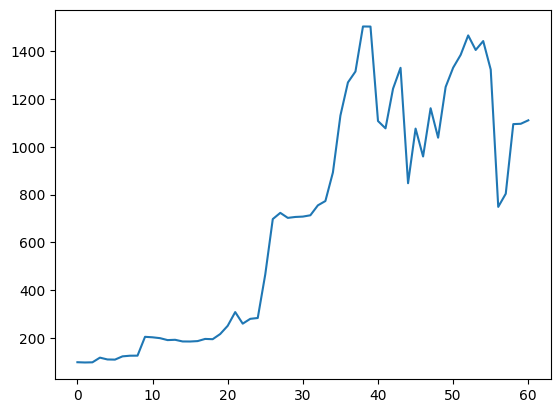

In [26]:
plt.plot(wealth[9])

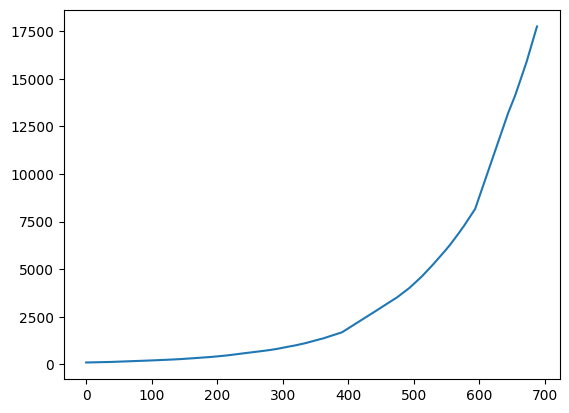

In [27]:
mean_w = np.mean(wealth, axis=0)

plt.plot(time_steps, mean_w)


In [30]:
weights.T.shape


(3, 60)

In [31]:
weights[i, :] * simulated_returns[:, i]

ValueError: operands could not be broadcast together with shapes (9,) (100000,400) 

In [35]:
simulated_returns[:, :, i].shape

(100000, 9)

In [45]:
weights[i, :]

array([0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111])

In [47]:
(weights[i, :] * simulated_returns[:, :, i])

array([[-0.00018527, -0.00058928, -0.00100247, ..., -0.00278764,
        -0.00323255, -0.00361954],
       [-0.00014065, -0.00033582, -0.00055706, ..., -0.0013156 ,
        -0.00156599, -0.00173906],
       [ 0.0008586 ,  0.00078052,  0.00044436, ..., -0.00044185,
        -0.00064367, -0.00076023],
       ...,
       [ 0.00173854,  0.00238531,  0.00310639, ...,  0.00604574,
         0.00682461,  0.00744153],
       [ 0.00118136,  0.001187  ,  0.00114913, ...,  0.00077756,
         0.00063796,  0.00046521],
       [ 0.00124304,  0.00165766,  0.00215388, ...,  0.00391462,
         0.00438823,  0.00471929]])

In [54]:
time_deltas[i]

np.float64(0.8905308742685263)

array([1.01515852, 1.00742902, 0.99971564, ..., 0.96324535, 0.9925288 ,
       0.97582372])

In [65]:
wealth


array([[1000000.        , 1003104.99106809,  945294.76870275, ...,
              0.        ,       0.        ,       0.        ],
       [1000000.        ,  949821.55621779,  961077.18825577, ...,
              0.        ,       0.        ,       0.        ],
       [1000000.        ,  983481.80957173,  997947.52537664, ...,
              0.        ,       0.        ,       0.        ],
       ...,
       [1000000.        ,  976264.66325025,  996949.9094198 , ...,
              0.        ,       0.        ,       0.        ],
       [1000000.        ,  970694.85831563,  975985.86009706, ...,
              0.        ,       0.        ,       0.        ],
       [1000000.        , 1011254.23190906,  986152.0647621 , ...,
              0.        ,       0.        ,       0.        ]])

In [27]:
wealth[:, i] * (1 + (weights[i, :] * simulated_returns[:, i]).sum()) ** time_deltas[i] - cashflows[i]

ValueError: operands could not be broadcast together with shapes (9,) (100000,400) 

In [19]:
annual_cov

Ticker,CNZ_MPF_NONE_2080,CNZ_MPF_NONE_3070,CNZ_MPF_NONE_4060,CNZ_MPF_NONE_5050,CNZ_MPF_NONE_6040,CNZ_MPF_NONE_7030,CNZ_MPF_NONE_8020,CNZ_MPF_NONE_9010,CNZ_MPF_NONE_9802
Ticker,,,,,,,,,
CNZ_MPF_NONE_2080,0.000078,0.000101,0.000123,0.000145,0.000166,0.000188,0.000209,0.000230,0.000246
CNZ_MPF_NONE_3070,0.000101,0.000135,0.000169,0.000203,0.000236,0.000269,0.000302,0.000335,0.000360
CNZ_MPF_NONE_4060,0.000123,0.000169,0.000217,0.000262,0.000308,0.000353,0.000399,0.000445,0.000479
CNZ_MPF_NONE_5050,0.000145,0.000203,0.000262,0.000319,0.000377,0.000434,0.000492,0.000550,0.000595
CNZ_MPF_NONE_6040,0.000166,0.000236,0.000308,0.000377,0.000447,0.000516,0.000587,0.000658,0.000712
CNZ_MPF_NONE_7030,0.000188,0.000269,0.000353,0.000434,0.000516,0.000599,0.000682,0.000765,0.000830
CNZ_MPF_NONE_8020,0.000209,0.000302,0.000399,0.000492,0.000587,0.000682,0.000777,0.000874,0.000948
CNZ_MPF_NONE_9010,0.000230,0.000335,0.000445,0.000550,0.000658,0.000765,0.000874,0.000984,0.001069
CNZ_MPF_NONE_9802,0.000246,0.000360,0.000479,0.000595,0.000712,0.000830,0.000948,0.001069,0.001161


In [ ]:

last_loss = 0
z = 0


smoothing_weight = 0
alpha = 0.8
base_iter_stop = 2000
iter_stop = base_iter_stop

withdrawal_base = [-10000] * RETIRE_YEAR + [40000] * (T-RETIRE_YEAR)

sharpness = 1e-6
while z < iter_stop:
    
    optimizer.zero_grad()
    simulated_returns = t_returns

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1
    wealth_over_time = np.zeros((T, n))
    w_t = torch.zeros((T, n))
    for i in range(T):
        # withdrawal = wealth.detach() * 0.05
    
        # withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)

        withdrawal = withdrawal_base[i] * inflation_adjustment
        withdrawal = torch.ones(n) * withdrawal

        cash_weight = 1 - weights[i, 0] 
        bond_weight = weights[i, 0] * weights[i, 1]
        stock_weight = weights[i, 0] * (1 - weights[i, 1])
        wealth = wealth * (1 + cash_weight * simulated_returns[:, 2, i] + bond_weight * simulated_returns[:, 0, i] + stock_weight * simulated_returns[:, 1, i]) - withdrawal
        # replace negative wealth with 0
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        w_t[i] = wealth
        wealth_over_time[i] = wealth.detach().numpy().flatten()
        inflation_adjustment *= (1 + inflation)
        
    loss = cost(wealth, weights, smoothing_weight, alpha)
    # loss = cost_2(w_t, weights, smoothing_weight, alpha)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        weights.clamp_(0.0, 1.0)
    print(loss.item())
    print(f"cash weight: {1-weights.mean(dim=0)[0].item()}")
    print(f"bond weight: {weights.mean(dim=0)[0].item() * weights.mean(dim=0)[1].item()}")
    
    print("destitution risk", torch.sum(wealth <= 0).item()/n)
    print("mean final wealth", torch.mean(wealth).item())
    # validation

    wealth = torch.full((1, n), initial_wealth)
    inflation_adjustment = 1

    for i in range(T):
        # withdrawal = wealth.detach() * 0.05
        # withdrawal = torch.where(withdrawal < 40000 * inflation_adjustment, torch.tensor(40000*inflation_adjustment), withdrawal)
        withdrawal = withdrawal_base[i] * inflation_adjustment
        withdrawal = torch.ones(n) * withdrawal
        cash_weight = 1 - weights[i, 0] 
        bond_weight = weights[i, 0] * weights[i, 1]
        stock_weight = weights[i, 0] * (1 - weights[i, 1])
        wealth = wealth * (1 + cash_weight * val_returns[:, 2, i] + bond_weight * val_returns[:, 0, i] + stock_weight * val_returns[:, 1, i]) - withdrawal
        wealth = torch.where(wealth < 0, torch.tensor(0.0), wealth)
        inflation_adjustment *= (1 + inflation)
    print("validation destitution risk", torch.sum(wealth <= 0).item()/n)
    print("validation mean final wealth", torch.mean(wealth).item())
    print("iteration", z)
    print("smoothing weight", smoothing_weight)
    print("alpha", alpha)
    clear_output(wait=True)

    # if z>10 and last_loss - loss.item() < 1e-8 and base_iter_stop == iter_stop:
    if z == base_iter_stop - 1:
        iter_stop = z + 3000
        alpha = 0.85
        smoothing_weight = 1/100

    if z == 100:
        sharpness = 1e-5
    if z == 300:
        sharpness = 1e-4
    if z == 700:
        sharpness = 1e-3
    if z == 1100:
        sharpness = 1e-2
    if z == 1500:
        sharpness = 1e-1
    z += 1
    last_loss = loss.item()


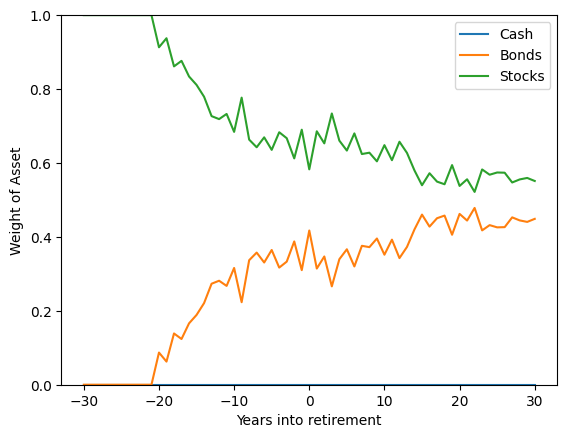

In [256]:
cash_weight = 1 - weights.detach().numpy()[:, 0]
bond_weight = weights.detach().numpy()[:, 0] * weights.detach().numpy()[:, 1]
stock_weight = weights.detach().numpy()[:, 0] * (1 - weights.detach().numpy()[:, 1])

years_into_retirement = np.arange(-RETIRE_YEAR, T-RETIRE_YEAR)

plt.plot(years_into_retirement, cash_weight)
plt.plot(years_into_retirement, bond_weight)
plt.plot(years_into_retirement, stock_weight)
plt.xlabel("Years into retirement")
plt.ylabel("Weight of Asset")
plt.ylim(0, 1)
plt.legend(["Cash", "Bonds", "Stocks"])

In [76]:
cost_ = -torch.sigmoid(wealth/initial_wealth).sum()/n
s_m1 = weights[0, :]
for z in range(1, weights.shape[0]):
    s_m1 = weights[z, :]
    x_z = weights[z-1, :]
    s_z = s_m1 - alpha * (x_z - s_m1)
    cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing_weight
    

In [227]:
((w_t.T / w_t.mean(axis=1))).T

tensor([[ 1.0000,  0.9998,  1.0000,  ...,  0.9999,  0.9999,  0.9999],
        [ 1.0136,  0.9435,  0.9602,  ...,  1.1040,  0.9965,  1.0257],
        [ 1.0232,  0.9993,  1.0112,  ...,  1.0854,  1.0266,  0.9268],
        ...,
        [ 0.0000,  4.1211,  0.0000,  ...,  0.0000,  0.0000, 10.6389],
        [ 0.0000,  3.7152,  0.0000,  ...,  0.0000,  0.0000, 10.9536],
        [ 0.0000,  3.1233,  0.0000,  ...,  0.0000,  0.0000, 14.2247]],
       grad_fn=<PermuteBackward0>)

In [226]:
w_t.shape

torch.Size([61, 100000])

In [ ]:
weights[:, z]

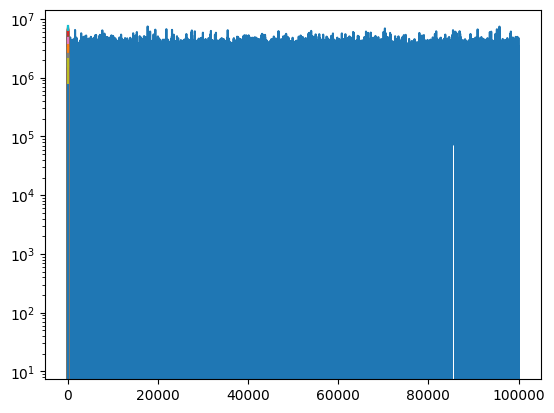

In [107]:
from matplotlib import pyplot as plt
plt.plot(wealth.detach().mean(axis=0))
plt.plot(wealth.detach().min(axis=0))
plt.plot(wealth.detach().max(axis=0))
plt.yscale("log")

In [21]:
simulated_returns.T[0].shape

(2, 10000)

In [26]:
weights.shape

(360, 2)